      Timestamp      Source IP   Destination IP  Protocol  Length
0  1.696895e+09  192.167.8.166  192.167.255.255      17.0      92
1  1.696895e+09  192.167.8.166  192.167.255.255      17.0      92
2  1.696895e+09            NaN              NaN       NaN      60
3  1.696895e+09            NaN              NaN       NaN      60
4  1.696895e+09            NaN              NaN       NaN      60
<class 'pandas.DataFrame'>
RangeIndex: 394136 entries, 0 to 394135
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   Timestamp       394136 non-null  float64
 1   Source IP       393502 non-null  str    
 2   Destination IP  393502 non-null  str    
 3   Protocol        393502 non-null  float64
 4   Length          394136 non-null  int64  
dtypes: float64(2), int64(1), str(2)
memory usage: 15.0 MB
None


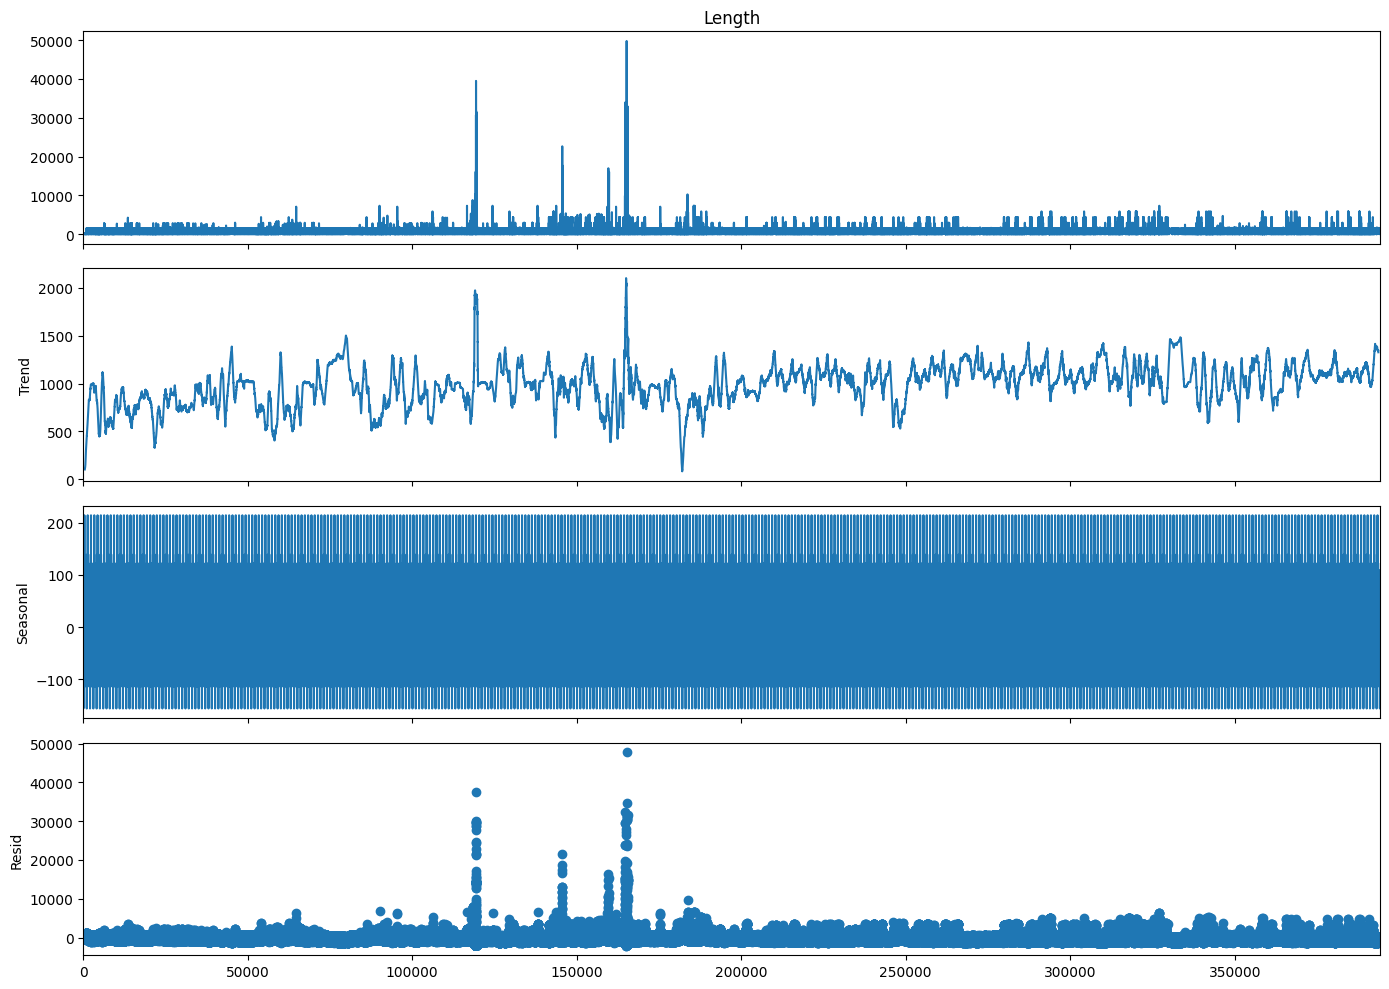

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
df = pd.read_csv("output1.csv")

print(df.head())
print(df.info())

import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
df = pd.read_csv("output1.csv")

# Convert Timestamp
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')

# Sort data
df = df.sort_values('Timestamp')

# Use Length as the time series
traffic = df['Length']

# Perform decomposition
result = seasonal_decompose(
    traffic,
    model='additive',
    period=1000   # You can also try 500 or 1440
)

# Plot
fig = result.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()


In [ ]:
print(df['Timestamp'].nunique())

392690


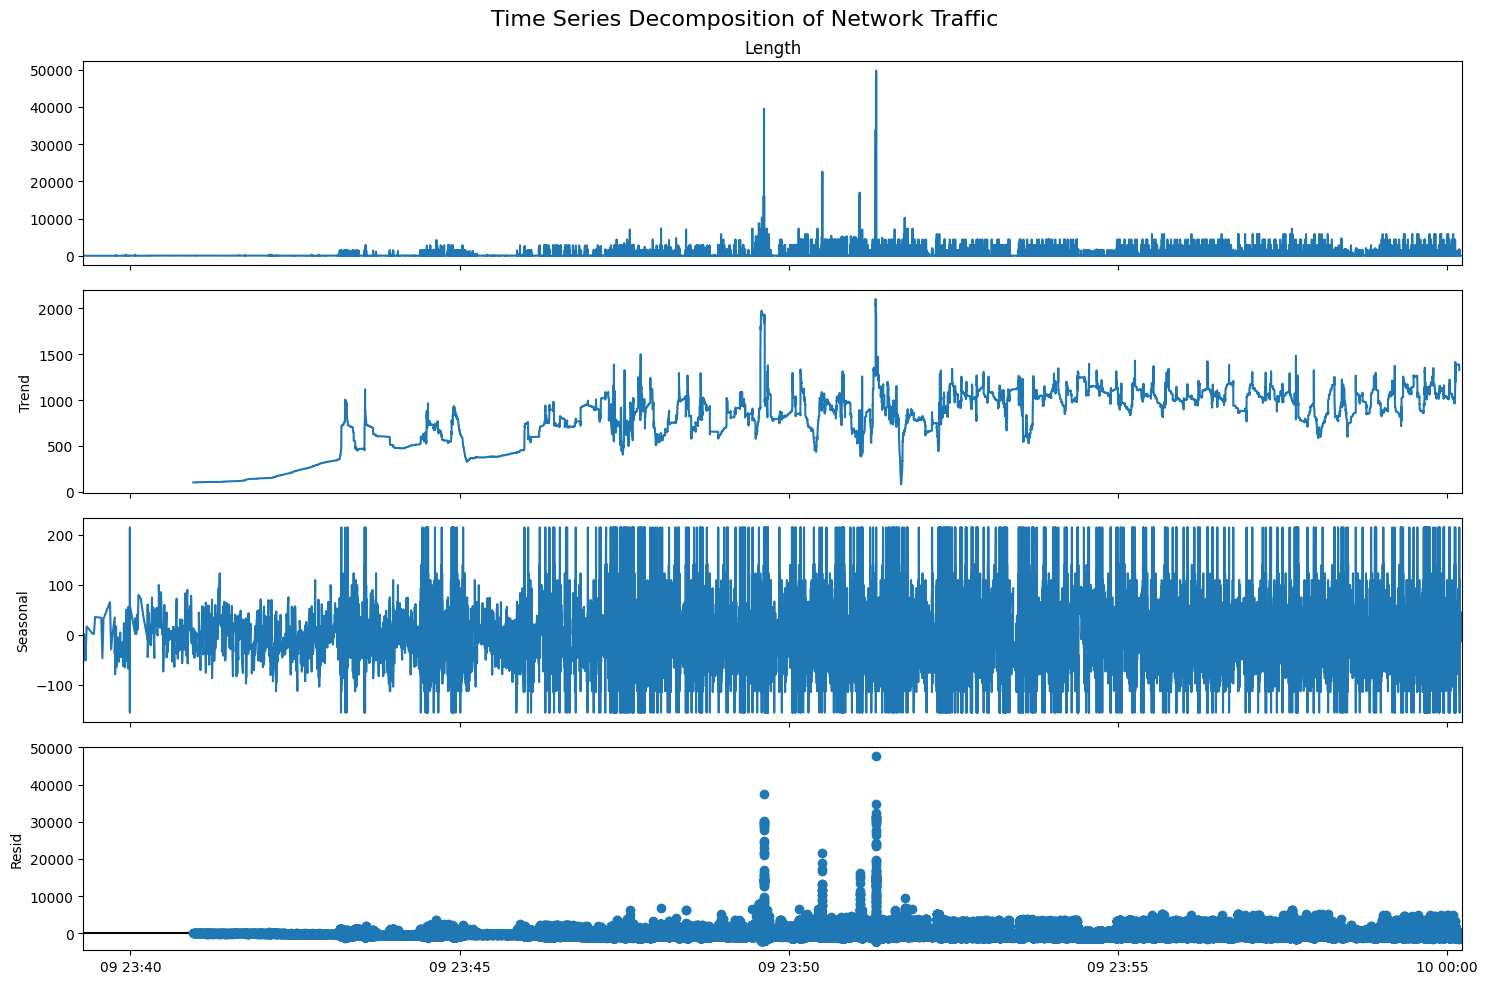

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Load dataset
df = pd.read_csv("output1.csv")

# Convert Unix timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')

# Sort by timestamp
df = df.sort_values('Timestamp')

# Set timestamp as index
df.set_index('Timestamp', inplace=True)

# Use Length as Total Traffic
traffic = df['Length']

# Fill missing values if any
traffic = traffic.interpolate()

# Perform Time Series Decomposition
decomposition = seasonal_decompose(
    traffic,
    model='additive',
    period=1000      # You can also try 500 or 1440
)

# Plot
fig = decomposition.plot()
fig.set_size_inches(15, 10)

plt.suptitle("Time Series Decomposition of Network Traffic", fontsize=16)
plt.tight_layout()
plt.show()